In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/sales.csv")
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df.head()


,Order_ID,Order_Date,Product,Category,Region,Quantity,Sales,Profit
0,ORD0001,2025-11-24,Smartphone,Electronics,South,1,26600.0,2660.0
1,ORD0002,2025-04-25,Headphones,Electronics,North,6,15000.0,2700.0
2,ORD0003,2025-10-30,Keyboard,Accessories,North,1,2200.0,374.0
3,ORD0004,2025-04-22,Office Chair,Furniture,South,5,35000.0,4900.0
4,ORD0005,2025-11-29,Keyboard,Accessories,East,2,3960.0,673.2


## 1. Data Overview

In [23]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)


Dataset shape: (500, 8)

Columns:
['Order_ID', 'Order_Date', 'Product', 'Category', 'Region', 'Quantity', 'Sales', 'Profit']

Data types:
Order_ID              object
Order_Date    datetime64[ns]
Product               object
Category              object
Region                object
Quantity               int64
Sales                float64
Profit               float64
dtype: object


In [24]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
Order_ID      0
Order_Date    0
Product       0
Category      0
Region        0
Quantity      0
Sales         0
Profit        0
dtype: int64

Duplicate rows: 0


## 2. Data Cleaning

In [25]:
df = df.drop_duplicates().copy()
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
df["Profit"] = pd.to_numeric(df["Profit"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df = df.dropna(subset=["Order_Date","Product","Category","Region","Quantity","Sales","Profit"])
df["Month"] = df["Order_Date"].dt.month
df["Month_Name"] = df["Order_Date"].dt.strftime("%b")
print("Cleaned shape:", df.shape)


Cleaned shape: (500, 10)


## 3. Key Business Metrics

In [26]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
total_units = df["Quantity"].sum()
avg_order_value = total_sales / total_orders

print(f"Total Sales: ₹{total_sales:,.2f}")
print(f"Total Profit: ₹{total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Units Sold: {total_units:,}")
print(f"Average Order Value: ₹{avg_order_value:,.2f}")


Total Sales: ₹24,625,055.00
Total Profit: ₹2,950,624.40
Total Orders: 500
Units Sold: 1,743
Average Order Value: ₹49,250.11


## 4. Product Analysis

In [27]:
product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)
print(product_sales)


Product
Laptop          10037500.0
Smartphone       5936000.0
Desk             2865000.0
Monitor          2744250.0
Office Chair     1695750.0
Keyboard          522720.0
Headphones        520625.0
Backpack          303210.0
Name: Sales, dtype: float64


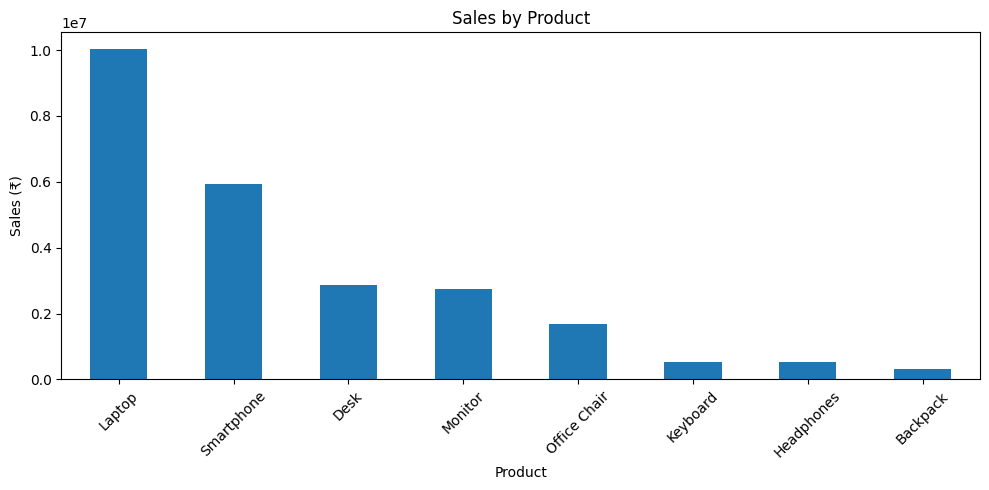

In [28]:
plt.figure(figsize=(10,5))
product_sales.plot(kind="bar")
plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/sales_by_product.png", dpi=150)
plt.show()


## 5. Regional Analysis

In [29]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print(region_sales)


Region
East     7556850.0
North    6213785.0
West     5798905.0
South    5055515.0
Name: Sales, dtype: float64


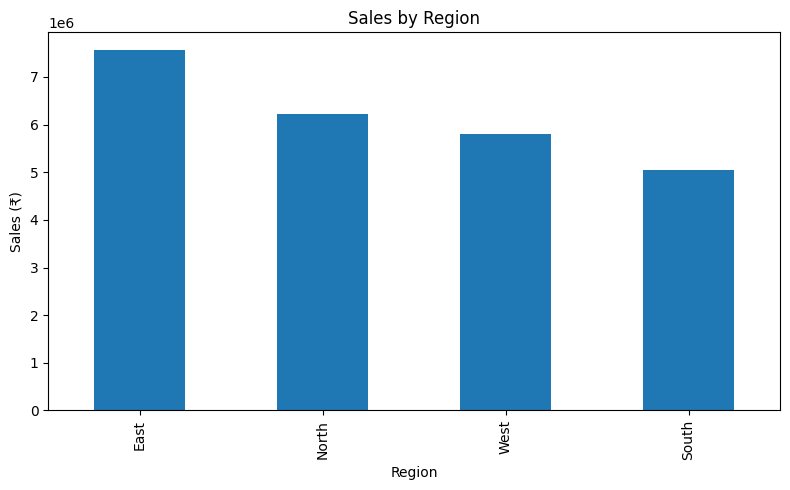

In [30]:
plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales (₹)")
plt.tight_layout()
plt.savefig("../images/sales_by_region.png", dpi=150)
plt.show()


## 6. Monthly Sales Trend

In [31]:
monthly_sales = df.groupby(df["Order_Date"].dt.to_period("M"))["Sales"].sum()
print(monthly_sales)


Order_Date
2025-01    2408925.0
2025-02    1629515.0
2025-03    2112685.0
2025-04    1365885.0
2025-05    2220210.0
2025-06    1175945.0
2025-07    1395370.0
2025-08    3545100.0
2025-09    1476025.0
2025-10    2874030.0
2025-11    2036160.0
2025-12    2385205.0
Freq: M, Name: Sales, dtype: float64


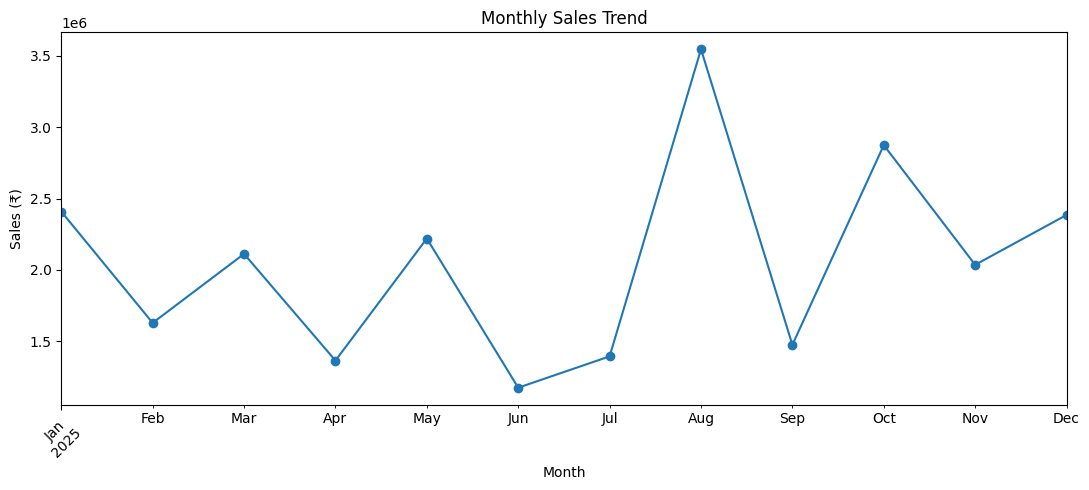

In [32]:
plt.figure(figsize=(11,5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/monthly_sales_trend.png", dpi=150)
plt.show()


## 7. Profitability

In [33]:
product_profit = df.groupby("Product")["Profit"].sum().sort_values(ascending=False)
print(product_profit)


Product
Laptop          1204500.0
Smartphone       593600.0
Monitor          356752.5
Desk             315150.0
Office Chair     237405.0
Headphones        93712.5
Keyboard          88862.4
Backpack          60642.0
Name: Profit, dtype: float64


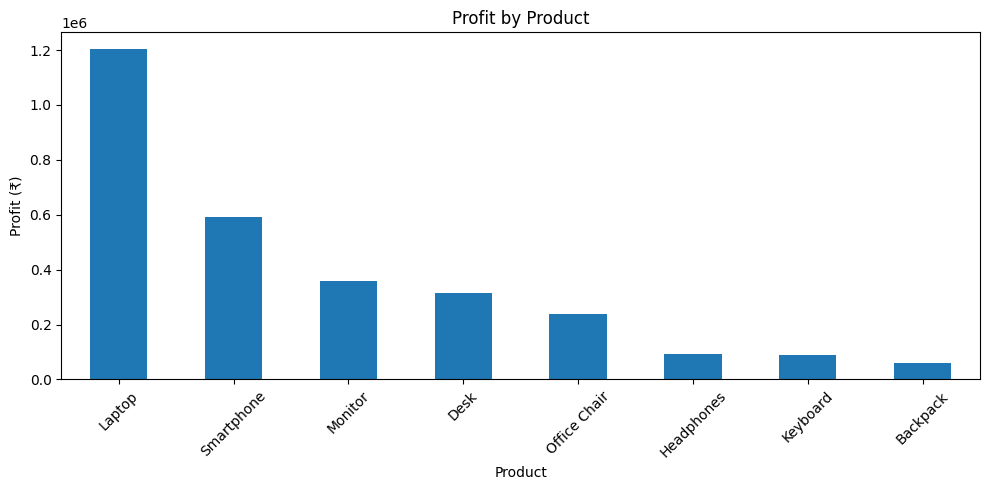

In [34]:
plt.figure(figsize=(10,5))
product_profit.plot(kind="bar")
plt.title("Profit by Product")
plt.xlabel("Product")
plt.ylabel("Profit (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/profit_by_product.png", dpi=150)
plt.show()


## 8. Correlation Analysis

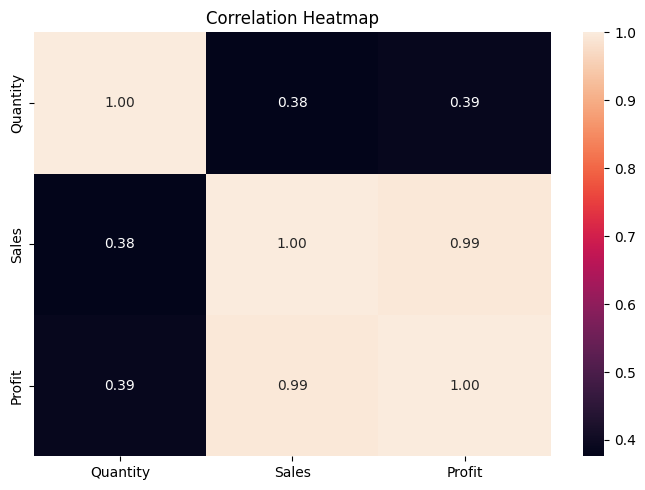

In [35]:
numeric_cols = ["Quantity","Sales","Profit"]
plt.figure(figsize=(7,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=150)
plt.show()


## 9. Business Insights

In [36]:
top_product = product_sales.idxmax()
top_region = region_sales.idxmax()
top_profit_product = product_profit.idxmax()
best_month = monthly_sales.idxmax()

print("Key Insights")
print(f"1. {top_product} generated the highest sales.")
print(f"2. {top_region} was the strongest region by sales.")
print(f"3. {top_profit_product} generated the highest total profit.")
print(f"4. {best_month} was the strongest month by sales.")
print(f"5. Total sales were ₹{total_sales:,.2f} with total profit of ₹{total_profit:,.2f}.")


Key Insights
1. Laptop generated the highest sales.
2. East was the strongest region by sales.
3. Laptop generated the highest total profit.
4. 2025-08 was the strongest month by sales.
5. Total sales were ₹24,625,055.00 with total profit of ₹2,950,624.40.


## Conclusion

The analysis identifies the strongest products, regions and periods and demonstrates a complete beginner-level data analytics workflow: data loading, cleaning, exploratory analysis, visualization and business interpretation.